<a href="https://colab.research.google.com/github/pach28/Binary-Prediction-with-a-Rainfall-Dataset/blob/main/Ensemble_Learning_por_Clusters_BPRD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

pt2

#instalamos librerias necesarias e iniciamos sesion de kaggle para acceder a la data

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests

sns.set_style('whitegrid')

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
import kagglehub
kagglehub.login()

Kaggle credentials set.
Kaggle credentials successfully validated.


In [ ]:
import os

# Download the competition dataset
playground_series_s5e2_path = kagglehub.competition_download('playground-series-s5e3')

# Extract the directory name from the downloaded path
dataset_dir = os.path.splitext(playground_series_s5e2_path)[0]

# Construct the correct paths to the train.csv and test.csv files
train_csv_path = os.path.join(dataset_dir, 'train.csv')
test_csv_path = os.path.join(dataset_dir, 'test.csv')
sample_submission_csv_path = os.path.join(dataset_dir, 'sample_submission.csv')
# Read the CSV files using the correct paths
train_df = pd.read_csv(train_csv_path)
test_df = pd.read_csv(test_csv_path)
sample_submission_df = pd.read_csv(sample_submission_csv_path)

100%|██████████| 59.0k/59.0k [00:00<00:00, 29.4MB/s]

Extracting files...


In [ ]:
#crear una columna llamada day_1 del 1 al 365, 6 veces
day_1 = pd.DataFrame(columns=['day_1'])
for i in range(6):
  rango = np.arange(1,366)
  day_1 = pd.concat([day_1,pd.DataFrame(rango,columns=['day_1'])], ignore_index=True)
#pegar day_1 al train_df
train_df = pd.concat([train_df,day_1.reset_index(drop=True)],axis=1) # Reset index of day_1 before concatenating

una vez resuelto el tema de los dias en desorden agregaremos columnas de mes y estacion del año

#Creacion de funcion para identificar las estaciones del año

In [ ]:
def crear_columnas_estaciones(df, columna_dia):
  """Crea columnas binarias para las estaciones del año."""

  df['Primavera'] = ((df[columna_dia] >= 80) & (df[columna_dia] <= 172)).astype(int)
  df['Verano'] = ((df[columna_dia] >= 173) & (df[columna_dia] <= 265)).astype(int)
  df['Otono'] = ((df[columna_dia] >= 266) & (df[columna_dia] <= 355)).astype(int)
  df['Invierno'] = (((df[columna_dia] >= 356) & (df[columna_dia] <= 365)) | ((df[columna_dia] >= 1) & (df[columna_dia] <= 79))).astype(int)
  #return df

In [ ]:
crear_columnas_estaciones(train_df,'day_1')

#creamos funcion que nos diga el dia y mes de cada registro

In [ ]:
#crearemos una columna que vaya por dias del mes
def crear_columnas_dia_mes(df, columna_dia_anio):
    """
    Crea columnas 'dia_del_mes' y 'mes' a partir de una columna de días del año.

    Args:
        df (pd.DataFrame): El DataFrame que contiene la columna de días del año.
        columna_dia_anio (str): El nombre de la columna que contiene los días del año (1-365).

    Returns:
        pd.DataFrame: El DataFrame con las nuevas columnas 'dia_del_mes' y 'mes'.
    """

    dias_acumulados = [0, 31, 59, 90, 120, 151, 181, 212, 243, 273, 304, 334, 365]  # Días acumulados al inicio de cada mes

    meses = []
    dias_del_mes = []

    for dia_anio in df[columna_dia_anio]:
        for mes_num in range(1, 13):
            if dia_anio <= dias_acumulados[mes_num]:
                meses.append(mes_num)
                dias_del_mes.append(dia_anio - dias_acumulados[mes_num - 1])
                break

    df['mes'] = meses
    df['dia_del_mes'] = dias_del_mes

In [ ]:
crear_columnas_dia_mes(train_df,'day_1')

asi podemos observar en que meses llueve mas

In [ ]:
#guardar los promedios por dia
promedios = pd.DataFrame(columns=['dia','promedio'])
for dia in train_df['day_1'].unique():
  prom = len(train_df[(train_df["day_1"]==dia) & (train_df["rainfall"]==1)])/6
  promedios = pd.concat([promedios,pd.DataFrame({'dia':[dia],'promedio':[prom]})],ignore_index=True)

In [ ]:
#agregar promedios a train_df
train_df = pd.merge(train_df,promedios,left_on='day_1',right_on='dia',how='left')

por ultimo haremos un pair plot de el nuevo df train con dabl

In [ ]:
!pip install dabl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 558.5/558.5 kB 8.7 MB/s eta 0:00:00


In [ ]:
#transformamos variables para ver el comportamiento en dabl
train_df_copy = train_df.copy()
train_df_copy['pressure_log'] = np.log(train_df_copy['pressure'])
#estandarizamos humidity, cloud, winddirection
train_df_copy['humidity_std'] = (train_df_copy['humidity']-train_df_copy['humidity'].mean())/train_df_copy['humidity'].std()
train_df_copy['cloud_std'] = (train_df_copy['cloud']-train_df_copy['cloud'].mean())/train_df_copy['cloud'].std()
train_df_copy['winddirection_std'] = (train_df_copy['winddirection']-train_df_copy['winddirection'].mean())/train_df_copy['winddirection'].std()

Target looks like classification
Linear Discriminant Analysis training set score: 0.820


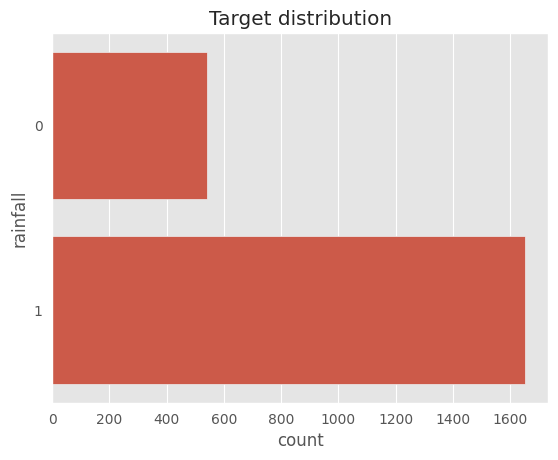

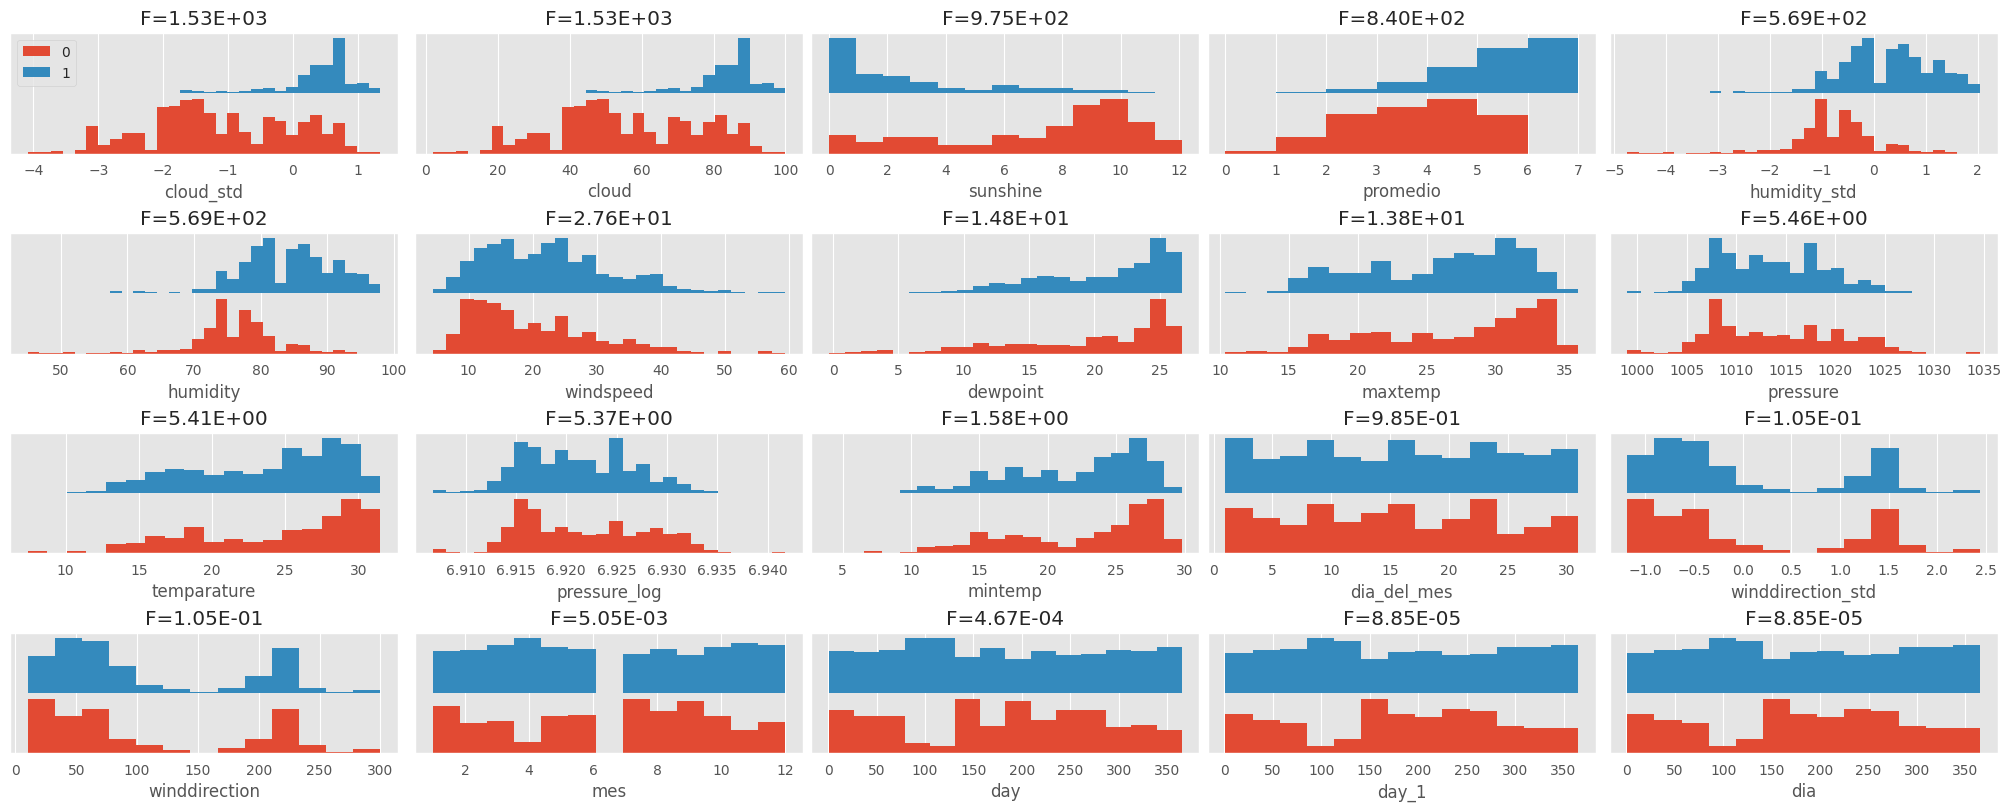

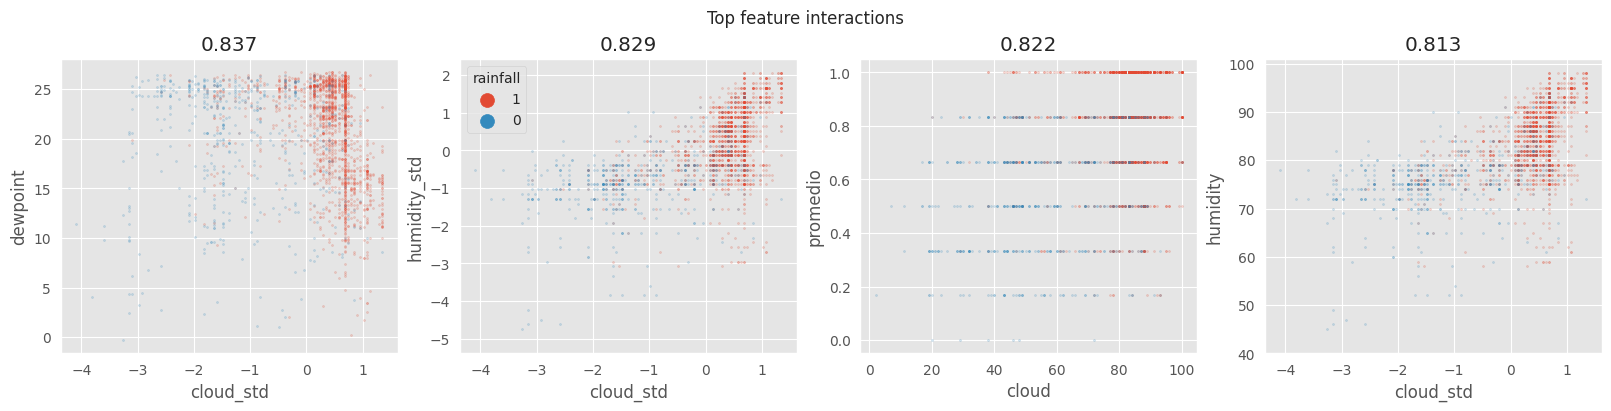

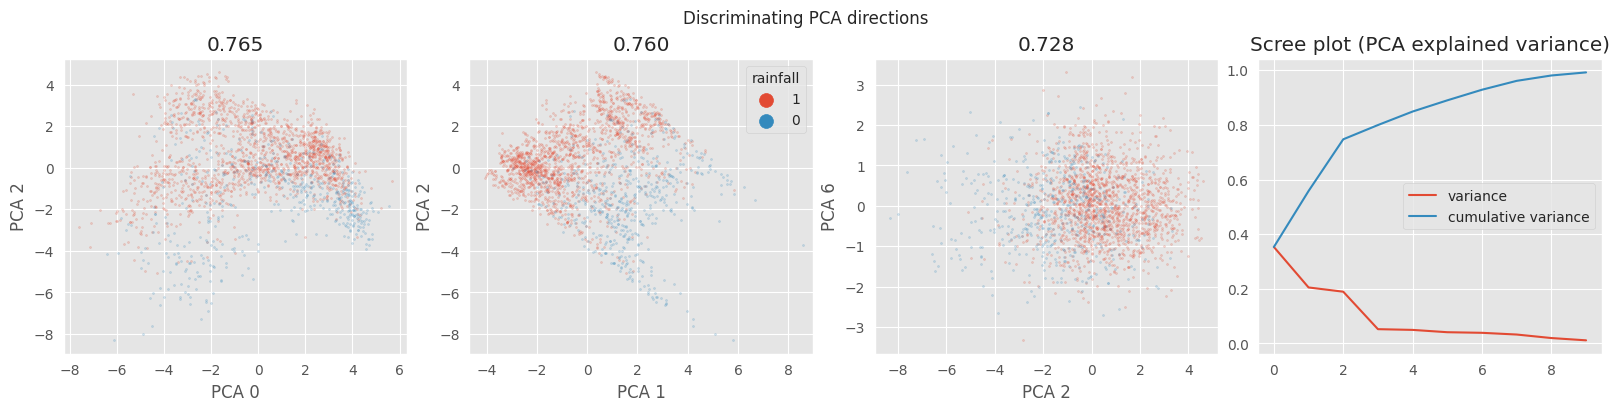

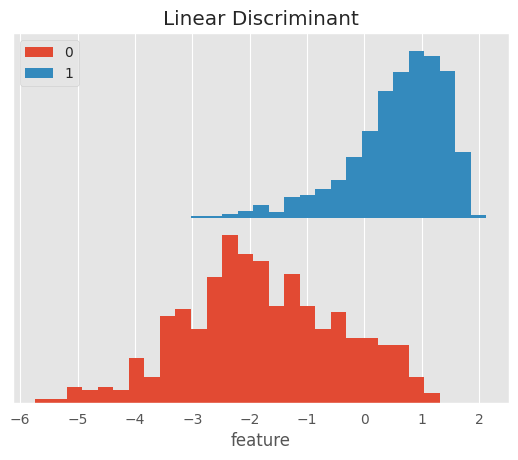

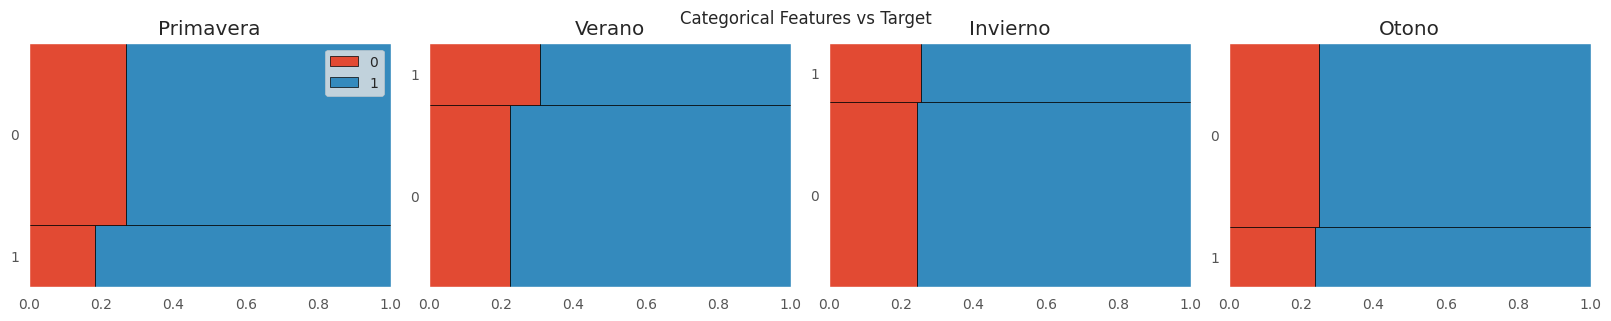

In [ ]:
import dabl
plt.style.use('ggplot')
warnings.filterwarnings('ignore')
dabl.plot(train_df_copy, target_col = 'rainfall')
# Acceder a la figura y los ejes
fig, ax = plt.gcf(), plt.gca()

# Eliminar la cuadrícula
ax.grid(False)

# Mostrar el gráfico
plt.show()

asi nos damos una idea de las caracteristicas que mas importan aunque suenen redundantes, las nubosidad, la temperatura, dewpoint, sunshine

#Ensemble learning

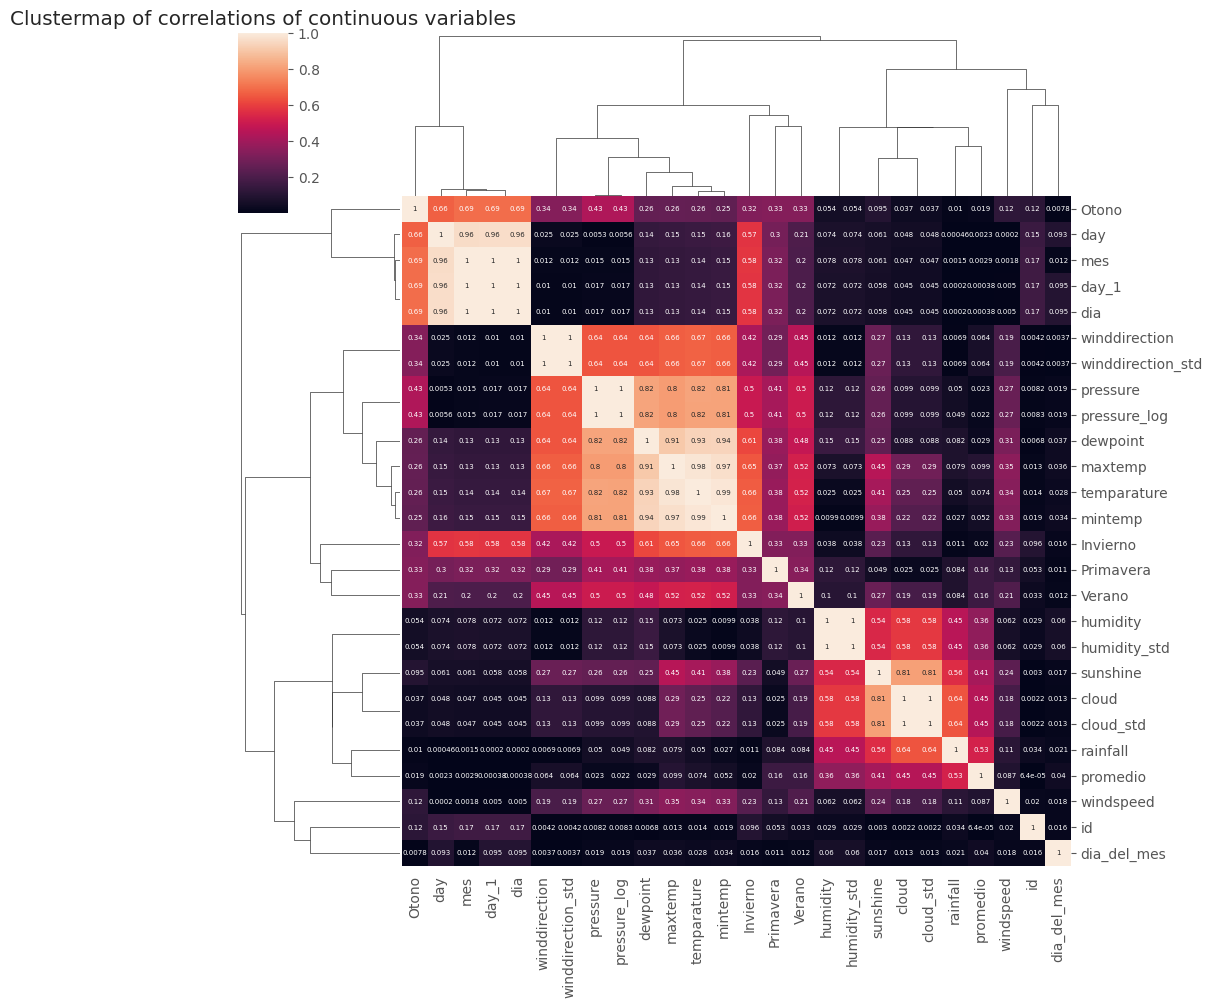

In [ ]:
# Clustermap of correlations of continuous variables
cont_data = train_df_copy
cont_data = cont_data.corr().abs()
map = sns.clustermap(cont_data, annot = True, annot_kws = {'size': 5})
plt.setp(map.ax_heatmap.yaxis.get_majorticklabels(),rotation = 0)
#titulo
plt.title('Clustermap of correlations of continuous variables')
plt.show()

con ayuda de un clustermap haremos la segmentacion de variables para los modelos de nivel base

In [ ]:
train_df_copy.columns

Index(['id', 'day', 'pressure', 'maxtemp', 'temparature', 'mintemp',
       'dewpoint', 'humidity', 'cloud', 'sunshine', 'winddirection',
       'windspeed', 'rainfall', 'day_1', 'Primavera', 'Verano', 'Otono',
       'Invierno', 'mes', 'dia_del_mes', 'dia', 'promedio', 'pressure_log',
       'humidity_std', 'cloud_std', 'winddirection_std'],
      dtype='object')

In [ ]:
base1_columnas = ['Otono','day_1','mes']
base2_columnas = ['winddirection','pressure_log','dewpoint','maxtemp','temparature','mintemp']
base3_columnas = ['Invierno','Primavera','Verano']
base4_columnas = ['humidity','sunshine','cloud','promedio']
base5_columnas = ['windspeed','dia_del_mes']

In [ ]:
train_df_copy['day_1'] = pd.to_numeric(train_df_copy['day_1'])

In [ ]:
#procedemos a entrenar un modelo de xgboostclassifier
import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import roc_auc_score, make_scorer

In [ ]:
X_1 = train_df_copy[base1_columnas]
X_2 = train_df_copy[base2_columnas]
X_3 = train_df_copy[base3_columnas]
X_4 = train_df_copy[base4_columnas]
X_5 = train_df_copy[base5_columnas]
y = train_df_copy['rainfall']

X_train1, X_test1, y_train1, y_test1 = train_test_split(X_1, y, test_size=0.2, random_state=28)
X_train2, X_test2, y_train2, y_test2 = train_test_split(X_2, y, test_size=0.2, random_state=28)
X_train3, X_test3, y_train3, y_test3 = train_test_split(X_3, y, test_size=0.2, random_state=28)
X_train4, X_test4, y_train4, y_test4 = train_test_split(X_4, y, test_size=0.2, random_state=28)
X_train5, X_test5, y_train5, y_test5 = train_test_split(X_5, y, test_size=0.2, random_state=28)

In [ ]:
'''
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='auc')  # Ajusta 'eval_metric' según sea necesario

# Definir la grilla de parámetros que deseas explorar
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01,.05, 0.1, 0.2],
    'max_depth': [3, 4, 5,6,7,8],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0]
}
# Configurar la validación cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Configurar la métrica de evaluación (ROC AUC)
roc_auc = make_scorer(roc_auc_score)
'''

"\nxgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='auc')  # Ajusta 'eval_metric' según sea necesario\n\n# Definir la grilla de parámetros que deseas explorar\nparam_grid = {\n    'n_estimators': [100, 200, 300],\n    'learning_rate': [0.01,.05, 0.1, 0.2],\n    'max_depth': [3, 4, 5,6,7,8],\n    'subsample': [0.8, 0.9, 1.0],\n    'colsample_bytree': [0.8, 0.9, 1.0]\n}\n# Configurar la validación cruzada estratificada\ncv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)\n\n# Configurar la métrica de evaluación (ROC AUC)\nroc_auc = make_scorer(roc_auc_score)\n"

In [ ]:
'''
# Realizar la búsqueda de la grilla con validación cruzada
grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, scoring=roc_auc, cv=cv, verbose=1, n_jobs=-1)
#1
grid_search.fit(X_train1, y_train1)
best_params1 = grid_search.best_params_
best_model1 = grid_search.best_estimator_
print("Mejores Parámetros:", best_params1)
#2
grid_search.fit(X_train2, y_train2)
best_params2 = grid_search.best_params_
best_model2 = grid_search.best_estimator_
print("Mejores Parámetros:", best_params2)
#3
grid_search.fit(X_train3, y_train3)
best_params3 = grid_search.best_params_
best_model3 = grid_search.best_estimator_
print("Mejores Parámetros:", best_params3)
#4
grid_search.fit(X_train4, y_train4)
best_params4 = grid_search.best_params_
best_model4 = grid_search.best_estimator_
print("Mejores Parámetros:", best_params4)
#5
grid_search.fit(X_train5, y_train5)
best_params5 = grid_search.best_params_
best_model5 = grid_search.best_estimator_
print("Mejores Parámetros:", best_params5)
'''

'\n# Realizar la búsqueda de la grilla con validación cruzada\ngrid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, scoring=roc_auc, cv=cv, verbose=1, n_jobs=-1)\n#1\ngrid_search.fit(X_train1, y_train1)\nbest_params1 = grid_search.best_params_\nbest_model1 = grid_search.best_estimator_\nprint("Mejores Parámetros:", best_params1)\n#2\ngrid_search.fit(X_train2, y_train2)\nbest_params2 = grid_search.best_params_\nbest_model2 = grid_search.best_estimator_\nprint("Mejores Parámetros:", best_params2)\n#3\ngrid_search.fit(X_train3, y_train3)\nbest_params3 = grid_search.best_params_\nbest_model3 = grid_search.best_estimator_\nprint("Mejores Parámetros:", best_params3)\n#4\ngrid_search.fit(X_train4, y_train4)\nbest_params4 = grid_search.best_params_\nbest_model4 = grid_search.best_estimator_\nprint("Mejores Parámetros:", best_params4)\n#5\ngrid_search.fit(X_train5, y_train5)\nbest_params5 = grid_search.best_params_\nbest_model5 = grid_search.best_estimator_\nprint("Mejores Par

Fitting 5 folds for each of 648 candidates, totalling 3240 fits
Mejores Parámetros: {'colsample_bytree': 1.0, 'learning_rate': 0.2, 'max_depth': 4, 'n_estimators': 300, 'subsample': 0.9}
Fitting 5 folds for each of 648 candidates, totalling 3240 fits
Mejores Parámetros: {'colsample_bytree': 0.9, 'learning_rate': 0.2, 'max_depth': 4, 'n_estimators': 100, 'subsample': 0.8}
Fitting 5 folds for each of 648 candidates, totalling 3240 fits
Mejores Parámetros: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Fitting 5 folds for each of 648 candidates, totalling 3240 fits
Mejores Parámetros: {'colsample_bytree': 0.8, 'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.9}
Fitting 5 folds for each of 648 candidates, totalling 3240 fits
Mejores Parámetros: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 300, 'subsample': 0.8}

In [ ]:
best_model1 = xgb.XGBClassifier(colsample_bytree=1.0, learning_rate=0.2, max_depth=4, n_estimators=300, subsample=0.9)
best_model2 = xgb.XGBClassifier(colsample_bytree=0.9, learning_rate=0.2, max_depth=4, n_estimators=100, subsample=0.8)
best_model3 = xgb.XGBClassifier(colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, subsample=0.8)
best_model4 = xgb.XGBClassifier(colsample_bytree=0.8, learning_rate=0.2, max_depth=3, n_estimators=100, subsample=0.9)
best_model5 = xgb.XGBClassifier(colsample_bytree=0.8, learning_rate=0.1, max_depth=5, n_estimators=300, subsample=0.8)
best_model1.fit(X_train1, y_train1)
best_model2.fit(X_train2, y_train2)
best_model3.fit(X_train3, y_train3)
best_model4.fit(X_train4, y_train4)
best_model5.fit(X_train5, y_train5)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [ ]:
# Realizar predicciones en el conjunto de prueba
#1
y_pred_proba1 = best_model1.predict_proba(X_test1)[:, 1]
# Calcular el ROC AUC en el conjunto de prueba
test_roc_auc1 = roc_auc_score(y_test1, y_pred_proba1)
print("ROC AUC en el Conjunto de Prueba model 1:", test_roc_auc1)
#2
y_pred_proba2 = best_model2.predict_proba(X_test2)[:, 1]
# Calcular el ROC AUC en el conjunto de prueba
test_roc_auc2 = roc_auc_score(y_test2, y_pred_proba2)
print("ROC AUC en el Conjunto de Prueba model 2:", test_roc_auc2)
#3
y_pred_proba3 = best_model3.predict_proba(X_test3)[:, 1]
# Calcular el ROC AUC en el conjunto de prueba
test_roc_auc3 = roc_auc_score(y_test3, y_pred_proba3)
print("ROC AUC en el Conjunto de Prueba model 3:", test_roc_auc3)
#4
y_pred_proba4 = best_model4.predict_proba(X_test4)[:, 1]
# Calcular el ROC AUC en el conjunto de prueba
test_roc_auc4 = roc_auc_score(y_test4, y_pred_proba4)
print("ROC AUC en el Conjunto de Prueba model 4:", test_roc_auc4)
#5
y_pred_proba5 = best_model5.predict_proba(X_test5)[:, 1]
# Calcular el ROC AUC en el conjunto de prueba
test_roc_auc5 = roc_auc_score(y_test5, y_pred_proba5)
print("ROC AUC en el Conjunto de Prueba model 5:", test_roc_auc5)

ROC AUC en el Conjunto de Prueba model 1: 0.6504934210526315
ROC AUC en el Conjunto de Prueba model 2: 0.6870126705653021
ROC AUC en el Conjunto de Prueba model 3: 0.5624086257309941
ROC AUC en el Conjunto de Prueba model 4: 0.9109862329434697
ROC AUC en el Conjunto de Prueba model 5: 0.5023300438596491


solo usaremos los primeros 4

In [ ]:
#sacar las probabilidades de X1,...,X4
y_pred_x1 = best_model1.predict_proba(X_1)[:, 1]
y_pred_x2 = best_model2.predict_proba(X_2)[:, 1]
y_pred_x3 = best_model3.predict_proba(X_3)[:, 1]
y_pred_x4 = best_model4.predict_proba(X_4)[:, 1]


In [ ]:
print(roc_auc_score(y, y_pred_x1))
print(roc_auc_score(y, y_pred_x2))
print(roc_auc_score(y, y_pred_x3))
print(roc_auc_score(y, y_pred_x4))

0.7875050505050505
0.9101644219977554
0.5657474747474748
0.9545645342312009


modelo 2 presenta sobreajuste al conjunto de train
modelo 4 mas efectivo, modelo 3 no muy efectivo pero es consntante

In [ ]:
#hacer un df de las preds
preds = pd.DataFrame({'x1':y_pred_x1,'x2':y_pred_x2,'x3':y_pred_x3,'x4':y_pred_x4})

In [ ]:
#agregar preds a train_df_copy
train_df_copy = pd.concat([train_df_copy,preds],axis=1)

In [ ]:
train_df_copy.columns

Index(['id', 'day', 'pressure', 'maxtemp', 'temparature', 'mintemp',
       'dewpoint', 'humidity', 'cloud', 'sunshine', 'winddirection',
       'windspeed', 'rainfall', 'day_1', 'Primavera', 'Verano', 'Otono',
       'Invierno', 'mes', 'dia_del_mes', 'dia', 'promedio', 'pressure_log',
       'humidity_std', 'cloud_std', 'winddirection_std', 'x1', 'x2', 'x3',
       'x4'],
      dtype='object')

modelo meta

In [ ]:
cols_meta = ['temparature','dewpoint','humidity','cloud','sunshine','winddirection','windspeed',
             'Primavera','Verano','Otono','Invierno','mes','dia_del_mes','promedio','pressure_log','cloud_std','x1','x2','x3','x4']

In [ ]:
Xmeta = train_df_copy[cols_meta]
ymeta = y
Xmeta_train, Xmeta_test, ymeta_train, ymeta_test = train_test_split(Xmeta, ymeta, test_size=0.2, random_state=28)
xgb_model_meta = xgb.XGBClassifier(use_label_encoder=False, eval_metric='auc')

In [ ]:
param_grid_meta = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01,.05, 0.1, 0.2],
    'max_depth': [4, 5,6,7,8],
    'subsample': [0.8, 0.9,1],
    'colsample_bytree': [0.8, 0.9,1]
}
cvmeta = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
roc_auc_meta = make_scorer(roc_auc_score)

In [ ]:
'''
grid_search_meta = GridSearchCV(estimator=xgb_model_meta, param_grid=param_grid_meta, scoring=roc_auc_meta, cv=cvmeta, verbose=1, n_jobs=-1)
grid_search_meta.fit(Xmeta_train, ymeta_train)
best_params_meta = grid_search_meta.best_params_
best_model_meta = grid_search_meta.best_estimator_
print("Mejores Parámetros:", best_params_meta)
'''

Fitting 5 folds for each of 648 candidates, totalling 3240 fits
Mejores Parámetros: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 100, 'subsample': 0.8}

Fitting 5 folds for each of 540 candidates, totalling 2700 fits
Mejores Parámetros: {'colsample_bytree': 0.9, 'learning_rate': 0.2, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.9}

In [ ]:
'''
grid_search_meta = GridSearchCV(estimator=xgb_model_meta, param_grid=param_grid_meta, scoring=roc_auc_meta, cv=cvmeta, verbose=1, n_jobs=-1)
grid_search_meta.fit(Xmeta, ymeta)
best_params_meta = grid_search_meta.best_params_
best_model_meta = grid_search_meta.best_estimator_
print("Mejores Parámetros:", best_params_meta)
'''

Fitting 5 folds for each of 540 candidates, totalling 2700 fits
Mejores Parámetros: {'colsample_bytree': 0.9, 'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 100, 'subsample': 0.8}


Fitting 5 folds for each of 540 candidates, totalling 2700 fits
Mejores Parámetros: {'colsample_bytree': 0.9, 'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 100, 'subsample': 0.8}

In [ ]:
best_model_meta = xgb.XGBClassifier(colsample_bytree=0.9, learning_rate=0.1, max_depth=4, n_estimators=100, subsample=0.8)
best_model_meta.fit(Xmeta, ymeta)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [ ]:
y_pred_meta = best_model_meta.predict_proba(Xmeta_test)[:, 1]
test_roc_auc_meta = roc_auc_score(ymeta_test, y_pred_meta)
print("ROC AUC en el Conjunto de Prueba:", test_roc_auc_meta)

ROC AUC en el Conjunto de Prueba: 0.983583089668616


In [ ]:
y_total = best_model_meta.predict_proba(Xmeta)[:, 1]
test_roc_auc_total = roc_auc_score(y, y_total)
print("ROC AUC en el Conjunto de Prueba:", test_roc_auc_total)

ROC AUC en el Conjunto de Prueba: 0.9980078563411897


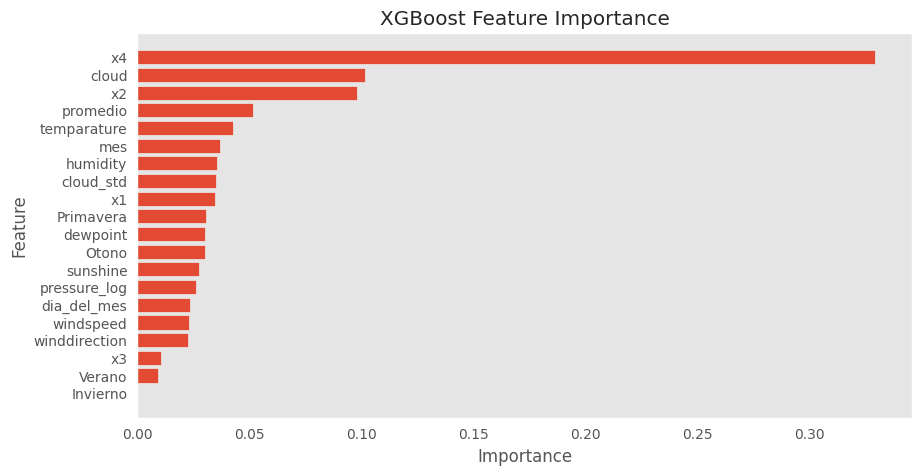

In [ ]:
FEATURES = train_df_copy[cols_meta].columns.tolist()
feature_importance = best_model_meta.feature_importances_
importance_df = pd.DataFrame({
    "Feature": FEATURES,
    "Importance": feature_importance
}).sort_values(by="Importance", ascending=False)
plt.figure(figsize=(10, 5))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")
plt.gca().invert_yaxis()
plt.grid(False)
plt.show()

(array([ 376.,   73.,   32.,   30.,   23.,   20.,   25.,   40.,   71.,
        1500.]),
 array([0.00244762, 0.10215427, 0.20186092, 0.30156758, 0.40127423,
        0.50098085, 0.6006875 , 0.70039415, 0.8001008 , 0.89980745,
        0.9995141 ]),
 <BarContainer object of 10 artists>)

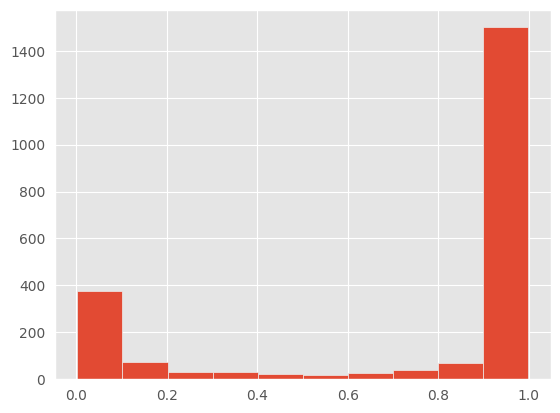

In [ ]:
plt.hist(y_total)

<Axes: >

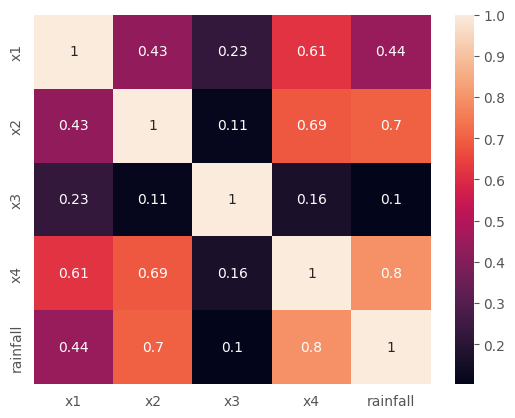

In [ ]:
#juntar Xmeta , ymeta
preds_meta = pd.concat([preds,ymeta],axis=1)
#heatmap
sns.heatmap(preds_meta.corr(),annot=True)

ahora hacemos todo para test_df

In [ ]:
#crear una columna llamada day_1 del 1 al 365, 2 veces
day_1 = pd.DataFrame(columns=['day_1'])
for i in range(2):
  rango = np.arange(1,366)
  day_1 = pd.concat([day_1,pd.DataFrame(rango,columns=['day_1'])], ignore_index=True)
#pegar day_1 al train_df
test_df = pd.concat([test_df,day_1.reset_index(drop=True)],axis=1) # Reset index of day_1 before concatenating

In [ ]:
crear_columnas_estaciones(test_df,'day_1')

In [ ]:
crear_columnas_dia_mes(test_df,'day_1')

In [ ]:
#unir test_df y promedios
test_df = pd.merge(test_df,promedios,left_on='day_1',right_on='dia',how='left')

In [ ]:
test_df['day_1'] = pd.to_numeric(test_df['day_1'])
test_df_copy = test_df.copy()
test_df_copy['pressure_log'] = np.log(test_df_copy['pressure'])
test_df_copy['humidity_std'] = (test_df_copy['humidity']-test_df_copy['humidity'].mean())/test_df_copy['humidity'].std()
test_df_copy['cloud_std'] = (test_df_copy['cloud']-test_df_copy['cloud'].mean())/test_df_copy['cloud'].std()
test_df_copy['winddirection_std'] = (test_df_copy['winddirection']-test_df_copy['winddirection'].mean())/test_df_copy['winddirection'].std()

In [ ]:
Xtest1 = test_df_copy[base1_columnas]
Xtest2 = test_df_copy[base2_columnas]
Xtest3 = test_df_copy[base3_columnas]
Xtest4 = test_df_copy[base4_columnas]

In [ ]:
pred_Xtest1 = best_model1.predict_proba(Xtest1)[:, 1]
pred_Xtest2 = best_model2.predict_proba(Xtest2)[:, 1]
pred_Xtest3 = best_model3.predict_proba(Xtest3)[:, 1]
pred_Xtest4 = best_model4.predict_proba(Xtest4)[:, 1]

In [ ]:
df_test = pd.DataFrame({'x1':pred_Xtest1,'x2':pred_Xtest2,'x3':pred_Xtest3,'x4':pred_Xtest4})

In [ ]:
test_df_copy = pd.concat([test_df_copy,df_test],axis=1)

In [ ]:
y_testmeta = best_model_meta.predict_proba(test_df_copy[cols_meta])[:, 1]

In [ ]:
sample_submission_df['rainfall'] = y_testmeta
sample_submission_df.to_csv('submission15.csv', index=False)

#menos variables

In [ ]:
cols_meta2 = ['temparature','cloud','promedio','x1','x2','x4','Otono','Primavera']

In [ ]:
model_meta_2 = xgb.XGBClassifier(colsample_bytree=0.9, learning_rate=0.1, max_depth=4, n_estimators=100, subsample=0.8)
model_meta_2.fit(Xmeta[cols_meta2],ymeta)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [ ]:
model_meta_2.predict_proba(test_df_copy[cols_meta2])[:, 1]
print(roc_auc_score(ymeta,model_meta_2.predict_proba(Xmeta[cols_meta2])[:, 1]))

0.9949652076318742


In [ ]:
preds = model_meta_2.predict_proba(test_df_copy[cols_meta2])[:, 1]
sample_submission_df['rainfall'] = preds
sample_submission_df.to_csv('submission19.csv', index=False)

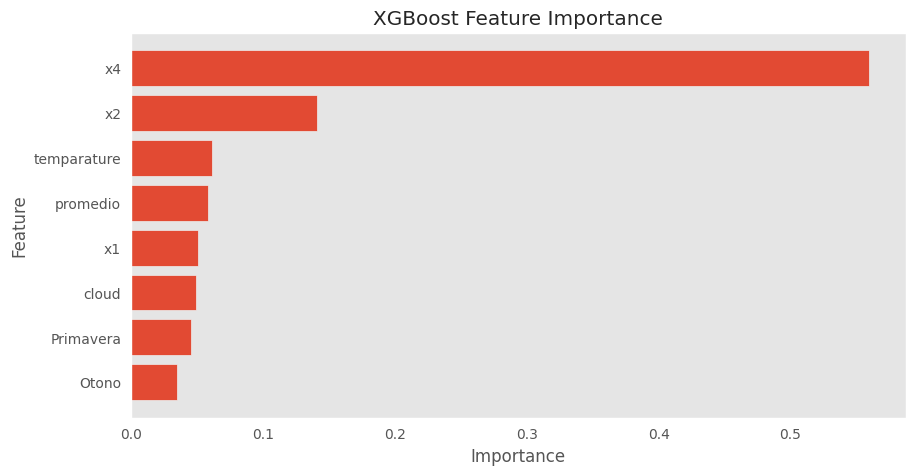

In [ ]:
FEATURES = train_df_copy[cols_meta2].columns.tolist()
feature_importance = model_meta_2.feature_importances_
importance_df = pd.DataFrame({
    "Feature": FEATURES,
    "Importance": feature_importance
}).sort_values(by="Importance", ascending=False)
plt.figure(figsize=(10, 5))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")
plt.gca().invert_yaxis()
plt.grid(False)
plt.show()

finalmente un dabl con train_df_copy

Target looks like classification
Showing only top 10 of 24 continuous features
Linear Discriminant Analysis training set score: 0.885


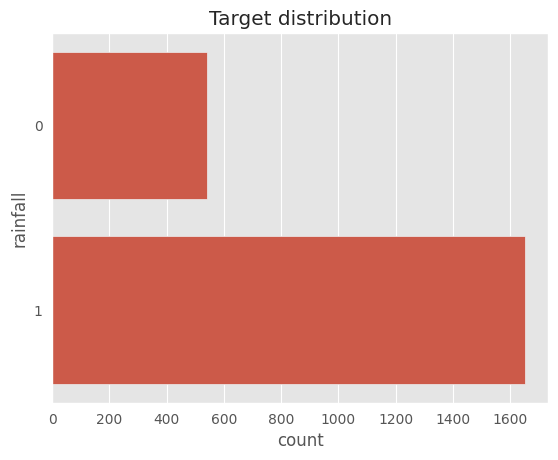

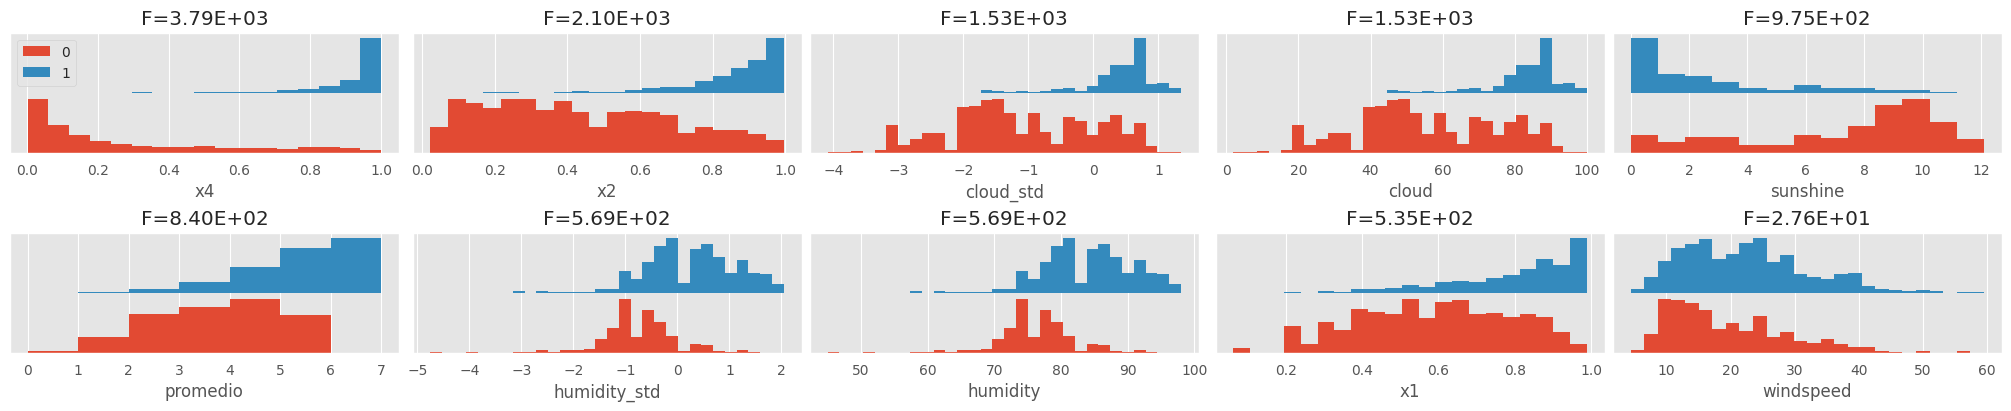

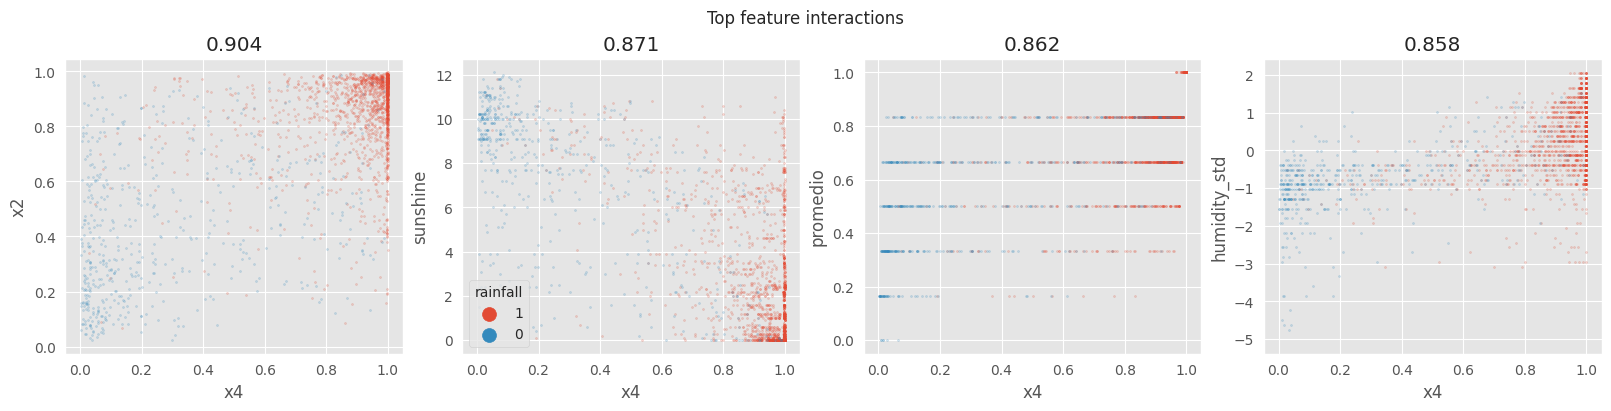

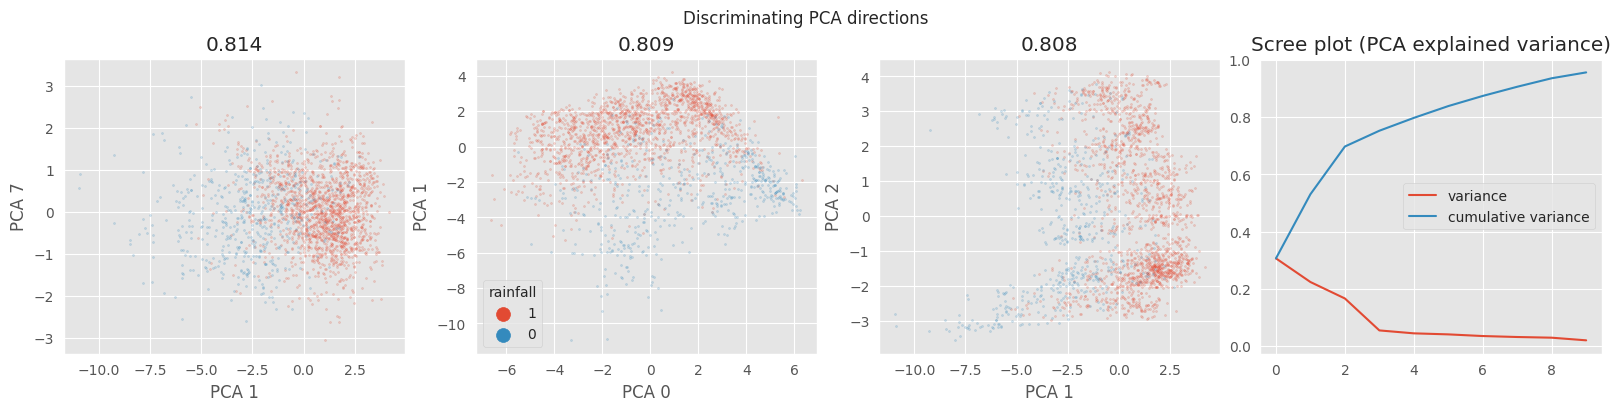

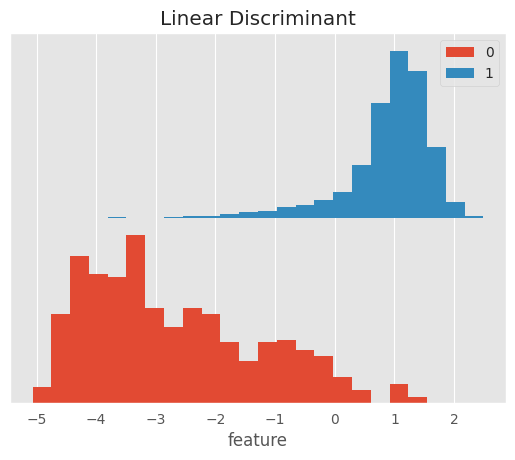

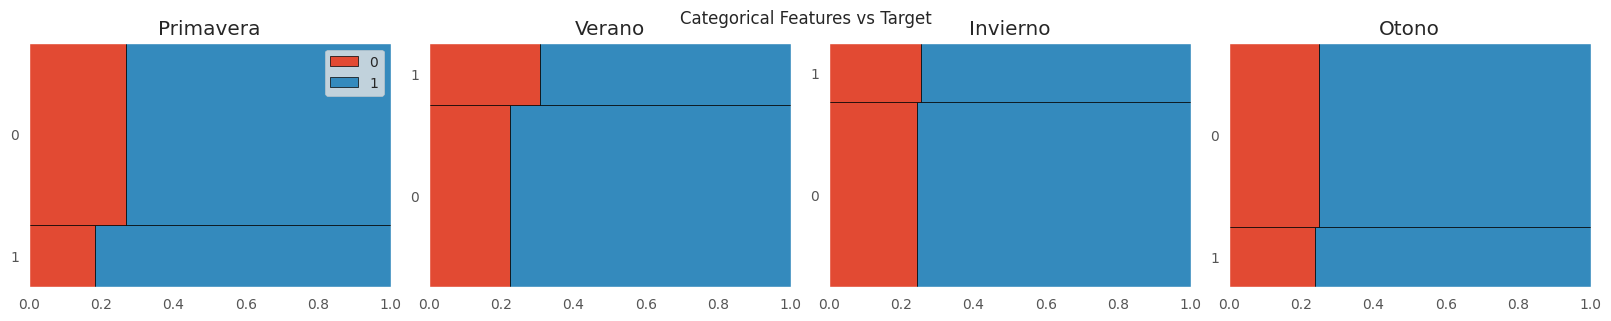

In [ ]:
plt.style.use('ggplot')
warnings.filterwarnings('ignore')
dabl.plot(train_df_copy, target_col = 'rainfall')
# Acceder a la figura y los ejes
fig, ax = plt.gcf(), plt.gca()

# Eliminar la cuadrícula
ax.grid(False)

# Mostrar el gráfico
plt.show()